# Qubit flux spectroscopy

In [34]:
from pathlib import Path

from qblox_lab.config.device import save_device_configuration
from qblox_lab.config.hardware import create_hardware_agent
from qblox_lab.config.sessions import CONFIG_DIR, SESSIONS
from qblox_lab.config.session_paths import save_config_snapshot, save_result_figures
from qblox_lab.experiments.cal08_qubit_flux_spectroscopy import QubitFluxSpectroscopy

## Run parameters

In [35]:
SESSION = SESSIONS["AS_QRC"]
HARDWARE_CONFIG = SESSION.hardware_config
DEVICE_CONFIG = SESSION.device_config
FLUX_CONFIG = SESSION.flux_config   # Idle bias for every listed qubit is applied before the pulsed sweep
OUTPUT_DIR = SESSION.output_dir
EXPERIMENT_NAME = "qubit_flux_spectroscopy"

QUBITS = ["q1"]
FREQUENCY_CENTER = None  # None: use each qubit's own f01 from the device config
FREQUENCY_WIDTH = 200e6
FREQUENCY_POINTS = 101
REPETITIONS = 100
DRIVE_AMPLITUDE = 0.05
# Flux pulse amplitudes are relative to whatever idle bias FLUX_CONFIG applies -- not absolute voltages.
FLUX_PULSE_START = -0.25
FLUX_PULSE_STOP = 0.25
FLUX_PULSE_POINTS = 31
PULSE_SETTLE_TIME = 1e-8
IDLE_RETURN_TIME = 1e-6

READOUT_AMPLITUDE = None
DRIVE_OUTPUT_ATTENUATION = None
READOUT_OUTPUT_ATTENUATION = None
READOUT_INPUT_ATTENUATION = None
READOUT_LO_FREQUENCY = None
TIMEOUT = 300
CREATE_DUMMY_CONNECTIONS = False

PLOT_RESULTS = True
SAVE_FITTED_DEVICE = SESSION.device_config  # Use None if parameter persistence is not required

## Hardware and experiment

In [36]:
import atexit

from qcodes.instrument import Instrument

hardware_agent = create_hardware_agent(
    hardware_configuration=HARDWARE_CONFIG,
    device_configuration=DEVICE_CONFIG,
    output_dir=OUTPUT_DIR,
    create_dummy_connections=CREATE_DUMMY_CONNECTIONS,
)

experiment = QubitFluxSpectroscopy(
    hardware_agent=hardware_agent,
    qubits=QUBITS,
    flux_config=FLUX_CONFIG,
)

atexit.register(Instrument.close_all)

<bound method Instrument.close_all of <class 'qcodes.instrument.instrument.Instrument'>>

## Measurement

In [37]:
dataset = experiment.run_measurement(
    frequency_center=FREQUENCY_CENTER,
    frequency_width=FREQUENCY_WIDTH,
    frequency_points=FREQUENCY_POINTS,
    repetitions=REPETITIONS,
    drive_amplitude=DRIVE_AMPLITUDE,
    flux_pulse_start=FLUX_PULSE_START,
    flux_pulse_stop=FLUX_PULSE_STOP,
    flux_pulse_points=FLUX_PULSE_POINTS,
    pulse_settle_time=PULSE_SETTLE_TIME,
    idle_return_time=IDLE_RETURN_TIME,
    readout_amplitude=READOUT_AMPLITUDE,
    drive_output_attenuation=DRIVE_OUTPUT_ATTENUATION,
    readout_output_attenuation=READOUT_OUTPUT_ATTENUATION,
    readout_input_attenuation=READOUT_INPUT_ATTENUATION,
    readout_lo_frequency=READOUT_LO_FREQUENCY,
    timeout=TIMEOUT,
)
dataset

/home/reny871224/micromamba/envs/qblox-training/lib/python3.10/site-packages/qblox_scheduler/backends/qblox/compiler_abc.py:285: UserWarning: Exact capabilities for ISA version 2.1 not found, using capabilities for version 2.2.
  warnings.warn(


<xarray.Dataset> Size: 125kB
Dimensions:           (acq_index_S21_q1: 3131)
Coordinates:
    flux_pulse_q1     (acq_index_S21_q1) float64 25kB -0.25 -0.25 ... 0.25 0.25
    frequency_q1      (acq_index_S21_q1) float64 25kB 3.424e+09 ... 3.624e+09
  * acq_index_S21_q1  (acq_index_S21_q1) int64 25kB 0 1 2 3 ... 3128 3129 3130
Data variables:
    S21_q1            (acq_index_S21_q1) complex128 50kB (-0.0012425302064418...
Attributes:
    tuid:     20260915-142107-700-cb302e

## Optional: Simulated data

In [38]:
# dataset = experiment.simulated_data(
#     frequency_center=FREQUENCY_CENTER,
#     frequency_width=FREQUENCY_WIDTH,
#     frequency_points=FREQUENCY_POINTS,
#     flux_pulse_start=FLUX_PULSE_START,
#     flux_pulse_stop=FLUX_PULSE_STOP,
#     flux_pulse_points=FLUX_PULSE_POINTS,
#     maximum_qubit_frequency=None,
#     frequency_shift=40e6,
#     sweet_spot=0.0,
#     linewidth=10e6,
#     noise=0.002,
#     seed=42,
# )

## Analysis

In [39]:
results = experiment.analysis()

for qubit, result in results.items():
    if result.success:
        print(
            f"{qubit}: sweet_spot={result.sweet_spot:.6f} V, "
            f"sweet_spot_frequency={result.sweet_spot_frequency / 1e9:.9f} GHz"
        )
    else:
        print(f"{qubit}: fit failed")

q1: sweet_spot=0.109015 V, sweet_spot_frequency=3.527078888 GHz


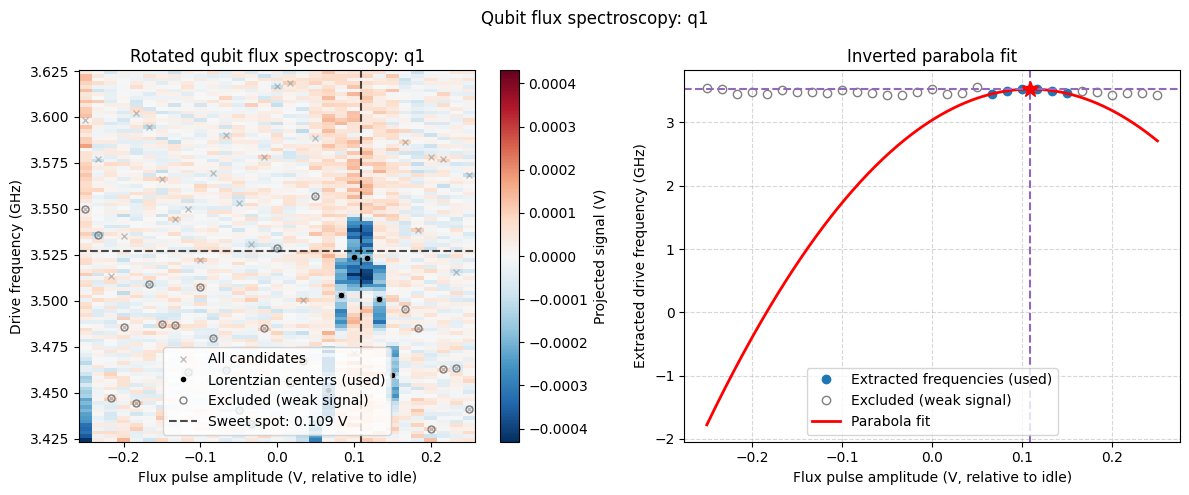

In [40]:
if PLOT_RESULTS:
    experiment.plot()

## Optional: apply and persist a selected operating point

In [41]:
SELECTED_FLUX_BIASES = None   # None: use every successfully fit qubit's sweet_spot, or set explicitly e.g. {"q1": 0.110337}
APPLY_SELECTED_FLUX_BIASES = True
SAVE_SELECTED_FLUX_BIASES = False
UPDATE_QUBIT_FREQUENCY = True   # Also write the fitted sweet_spot_frequency to clock_freqs.f01 for the same qubits

In [42]:
if APPLY_SELECTED_FLUX_BIASES:
    flux_biases_to_apply = SELECTED_FLUX_BIASES
    if flux_biases_to_apply is None:
        flux_biases_to_apply = {
            qubit: result.sweet_spot
            for qubit, result in experiment.results.items()
            if result.success
        }
        if not flux_biases_to_apply:
            raise ValueError("No qubit has a successful fit -- set SELECTED_FLUX_BIASES manually.")

    applied_biases = experiment.apply_flux_biases(flux_biases_to_apply)
    for qubit, value in applied_biases.items():
        print(f"{qubit}: live flux bias = {value:.6f} V")

    if SAVE_SELECTED_FLUX_BIASES:
        if FLUX_CONFIG is None:
            raise ValueError("Set FLUX_CONFIG to a file path before saving.")
        saved_path = experiment.save_flux_biases(
            FLUX_CONFIG,
            flux_biases_to_apply,
        )
        print(f"Saved flux operating points to {saved_path}")

    if UPDATE_QUBIT_FREQUENCY:
        # Updates clock_freqs.f01 in-memory for every measured qubit with a
        # successful fit -- if flux_biases_to_apply was narrowed to a subset
        # above, this can still update qubits outside that subset.
        updated_qubits = experiment.update_device()
        for qubit_name in updated_qubits:
            f01 = experiment.results[qubit_name].sweet_spot_frequency
            print(f"{qubit_name}: clock_freqs.f01 updated to {f01 / 1e9:.9f} GHz")

        # The update above only changes the in-memory QuantumDevice -- write
        # it back to disk so dut_config_AS_QRC.json reflects it too, same
        # pattern as every other runNN_*.ipynb (SAVE_FITTED_DEVICE).
        if SAVE_FITTED_DEVICE is not None:
            saved_device_path = save_device_configuration(
                hardware_agent.quantum_device,
                SAVE_FITTED_DEVICE,
            )
            print(f"Updated device configuration saved to {saved_device_path}")

q1: live flux bias = 0.109010 V
q1: clock_freqs.f01 updated to 3.527078888 GHz
Updated device configuration saved to /home/reny871224/qblox-measurement-nodes/config/dut_config_AS_QRC.json


In [10]:
if PLOT_RESULTS and experiment.figures:
    save_result_figures(SESSION, dataset, EXPERIMENT_NAME, experiment.figures)
save_config_snapshot(SESSION, dataset, EXPERIMENT_NAME)


## Release hardware connection

In [ ]:
from qcodes.instrument import Instrument

Instrument.close_all()